# 05 — Production Inference Wrapper

**FusionCore v2 — Phase Ph-v2.4**

The deployable deliverable of the FusionCore programme. This notebook
defines the `FusionCorePredictor` class — a single object that ingests raw
C-MAPSS-format engine telemetry (one or more rows per engine cycle) and
returns calibrated RUL intervals and three-class operational
classification probabilities. The wrapper composes:

- the **Stage B PiNet** trained in Ph-v2.0 (with the v1.P14 mitigations),
- the **v0 frozen statistical pipeline** (regime K-Means, per-regime
  z-score, Yeo–Johnson on CPR/E_thermal),
- the **v1.A-1 η_c regime z-score** parameters,
- the **v1.A-2 Cox PH** β vector for hazard_score,
- the **v2.A-2 conformal RUL quantiles** at α ∈ {0.05, 0.10, 0.20},
- the **v2.A-3 temperature scaling** for the risk-band softmax,

into one TorchScriptable inference path. A demonstration is run on five
representative engines from the NASA Test set and a per-engine RCM-style
report is emitted.

### Reading order at session start

1. `../../MICHELE-CLAUDE.md` — personal profile and workflow
2. `../v2CLAUDE.md` — particularly §3 New v2 Artefacts and §5 phase plan
3. `../../v1/v1CLAUDE.md` — especially §14 lessons P5–P14
4. `../../CLAUDE.md` (legacy root) — Iron Wall Protocol §9
5. `../../reports/FusionCore_v1_Master_Roadmap.pdf`

### Phase scope

| Phase | Description | Acceptance gate |
|---|---|---|
| **Ph-v2.4** | Build `FusionCorePredictor` wrapping all v0/v1/v2 artefacts; demonstrate end-to-end on representative test engines; export TorchScript; produce per-engine RCM-style reports | Programmatic gate (16 checks) |

### Operational classification (inherited from v1CLAUDE.md §4.5)

| Class | RUL range | Action |
|---|---|---|
| Healthy | RUL ≥ 80 | Normal operations |
| Warning | 30 ≤ RUL < 80 | Trigger logistics planning |
| Critical | RUL < 30 | AOG / immediate maintenance |

### Wrapper contract

```python
predictor = FusionCorePredictor.from_artefacts(v1_outputs, v2_outputs)
report = predictor.predict_engine(raw_engine_dataframe)
# report = {
#   "rul_pred":          float,           # point estimate (cycles)
#   "rul_interval_95":   (lo, hi),        # (1 - 0.05) conformal interval
#   "rul_interval_90":   (lo, hi),
#   "rul_interval_80":   (lo, hi),
#   "risk_band_pred":    int,             # 0=H, 1=W, 2=C
#   "risk_band_probs":   [pH, pW, pC],    # temperature-scaled
#   "risk_band_label":   "Critical" | "Warning" | "Healthy",
#   "operational_action": str,
# }
```

### Outputs (under `v2/outputs/`)

| File | Purpose |
|---|---|
| `phase_v2_4_predictor.pkl` | Full pickled `FusionCorePredictor` — single deployment artefact |
| `phase_v2_4_pinet_scripted.pt` | TorchScript export of the Stage B PiNet for Python-free inference |
| `phase_v2_4_demo_predictions.parquet` | Demo predictions on five representative test engines |
| `phase_v2_4_demo_reports/` | One markdown RCM-style report per demo engine |
| `phase_v2_4_demo_visual.png` | Predicted RUL trajectory with conformal interval band, per demo engine |

### References

- Vovk, V., Gammerman, A. and Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
- Lei, J. *et al.* (2018). Distribution-free predictive inference for regression. *JASA* 113(523).
- Guo, C., Pleiss, G., Sun, Y. and Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML*.
- Bai, S., Kolter, J. Z. and Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. *arXiv 1803.01271*.
- Walsh, P. P. and Fletcher, P. (2004). *Gas Turbine Performance*, 2nd edn. Blackwell / Wiley.
- Cox, D. R. (1972). Regression models and life-tables. *J. Royal Statistical Society: B* 34(2).
- Nowlan, F. S. and Heap, H. F. (1978). *Reliability-Centered Maintenance*. United Airlines / DoD.

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================

import sys, os, json, pickle, warnings, time, copy
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional, Union

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")

Python  : 3.13.13
PyTorch : 2.11.0


## Cell 2 — FusionCore Palette and Matplotlib Configuration

In [2]:
# ============================================================================
# Cell 2 — FusionCore Palette
# ============================================================================

FC_DARK_BLUE  = "#0D1B2A"; FC_NAVY = "#1B3A5C"; FC_ORANGE = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"; FC_STEEL = "#4A6274"; FC_CHARCOAL = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]
plt.rcParams.update({
    "figure.figsize": (14, 5), "figure.dpi": 110,
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": FC_CHARCOAL, "axes.labelcolor": FC_CHARCOAL,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=FC_PALETTE),
    "xtick.color": FC_CHARCOAL, "ytick.color": FC_CHARCOAL,
    "legend.fontsize": 9, "legend.framealpha": 0.9,
    "grid.color": FC_LIGHT_GREY, "grid.alpha": 0.6, "grid.linestyle": ":",
})
print("Palette configured.")

Palette configured.


## Cell 3 — Project Constants

In [3]:
# ============================================================================
# Cell 3 — Project Constants and Paths
# ============================================================================

PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V0_OUT       = PROJECT_ROOT / "v0" / "outputs"
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"
V2_OUT       = PROJECT_ROOT / "v2" / "outputs"
DATASETS     = PROJECT_ROOT / "Datasets" / "CMAPSS"
V2_OUT.mkdir(parents=True, exist_ok=True)

# Architecture constants (matched to Notebook 02 byte-for-byte).
W                 = 30
N_FEATURES        = 89
N_PHYSICS_TOKENS  = 11
TCN_HIDDEN        = 64
TCN_KERNEL        = 3
TCN_DILATIONS     = [1, 2, 4, 8, 16]
TCN_DROPOUT       = 0.25      # Stage B value; dropout is parameterless and eval mode short-circuits, but kept consistent with NB 02–04
EMBED_DIM         = 128
PHYS_HIDDEN       = 50
PHYS_OUT          = 32
HEAD_HIDDEN       = 64
N_RISK_CLASSES    = 3
RUL_CAP           = 125

# Risk-band thresholds.
HEALTHY_TH        = 80
WARNING_TH        = 30

# η_c thermodynamic constant.
GAMMA_AIR         = 1.4

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Conformal coverage levels exposed by the wrapper.
CONFORMAL_ALPHAS = (0.05, 0.10, 0.20)   # 95 / 90 / 80 % nominal coverage

print(f"Device : {DEVICE}")
print(f"Conformal α targets : {CONFORMAL_ALPHAS}")

Device : mps
Conformal α targets : (0.05, 0.1, 0.2)


---

## Part A — PiNet Architecture (re-defined inline)

The same architecture as Notebook 02. Re-defined here so the wrapper is
self-contained — `FusionCorePredictor` can be unpickled and used in any
deployment environment without depending on the v1 source tree.

In [4]:
# ============================================================================
# Cell 4 — PiNet Architecture (byte-for-byte match with v1 Notebook 02)
# ============================================================================

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x):
        return self.conv(F.pad(x, (self.left_pad, 0)))


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1,2)).transpose(1,2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1,2)).transpose(1,2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h


class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x.transpose(1,2)).transpose(1,2)


class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        return self.net(torch.cat([x_phys[:, -1, :], regime_w.unsqueeze(-1)], dim=-1))


class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN * 2 + PHYS_OUT
        h = (ind + EMBED_DIM) // 2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x):
        return self.net(x)


class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn       = TCN()
        self.physics   = PhysicsMLP()
        self.fusion    = FusionMLP()
        self.rul_head  = RULHead()
        self.risk_head = RiskBandHead()
    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":    self.rul_head(embed),
                "risk_logits": self.risk_head(embed),
                "embed":       embed}
print("PiNet class defined.")

PiNet class defined.


---

## Part B — `FusionCorePredictor` Class

The wrapper. It composes everything the operations dashboard needs:

- A `from_artefacts()` classmethod that loads (in order of priority):
  1. The Stage B PiNet from `phase_v2_0_pinet_stage_b_best.pt` if present,
     otherwise the Ph-v1.3 best, otherwise the Ph-v1.2 init (smoke).
  2. The conformal quantiles from `phase_v2_1_conformal.pkl` if present,
     otherwise a `None` placeholder (intervals disabled).
  3. The temperature scalar from `phase_v2_2_temperature.pkl` if present,
     otherwise $T = 1$ (no scaling).
  4. The v0 frozen pipeline (regime dictionary, Yeo–Johnson transformer).
  5. The v1 η_c regime parameters and Cox PH model.
  6. The 89-feature column manifest.
- A `predict_engine()` method that takes a raw engine dataframe in
  C-MAPSS schema and returns the full report dict per the Cell 0
  contract.
- A `to_torchscript()` method that exports the PiNet portion for
  language-agnostic deployment.

The wrapper degrades gracefully — if any v2-specific artefact is missing
(e.g., conformal calibration not yet run), it emits clear warnings and
operates without that feature, rather than failing.

In [5]:
# ============================================================================
# Cell 5 — FusionCorePredictor — Composing All Artefacts
# ============================================================================

CMAPSS_COLUMNS = [
    "unit_id", "cycle", "op1", "op2", "op3",
    "s1","s2","s3","s4","s5","s6","s7","s8","s9","s10",
    "s11","s12","s13","s14","s15","s16","s17","s18","s19","s20","s21",
]


class FusionCorePredictor:
    """Production inference wrapper for FusionCore v₁/v₂.

    Attributes
    ----------
    pinet : PiNet
        The trained two-branch model.
    pinet_provenance : str
        Which checkpoint was loaded (v2 Stage B / v1 Stage A best / v1 init).
    regime_z_params : dict
        v0 frozen per-regime z-score parameters keyed by subset_origin → regime_id.
    yj_transformer : sklearn-compatible
        v0 frozen Yeo–Johnson transformer for CPR and E_thermal.
    eta_c_regime_params : dict
        v1.A-1 per-regime z-score parameters for η_c.
    cox_model : lifelines.CoxPHFitter
        v1.A-2 Cox PH model — covariates listed in v1CLAUDE.md §17.2 A-2.
    cox_covariates : list[str]
        Ten covariates the Cox PH model expects.
    feature_names : list[str]
        The 89-column manifest in alphabetical order.
    physics_token_indices : list[int]
        Indices of the ten per-cycle physics tokens within the 89-feature axis.
    conformal_q : dict[float, float] | None
        α → half-width q from v2.A-2.  None if calibration not run.
    temperature : float
        v2.A-3 temperature for the risk-band softmax.  1.0 if not run.
    device : torch.device
    """

    def __init__(self, *, pinet, pinet_provenance, regime_z_params, yj_transformer,
                 eta_c_regime_params, cox_model, cox_covariates, feature_names,
                 physics_token_indices, conformal_q, temperature, device):
        self.pinet                 = pinet
        self.pinet_provenance      = pinet_provenance
        self.regime_z_params       = regime_z_params
        self.yj_transformer        = yj_transformer
        self.eta_c_regime_params   = eta_c_regime_params
        self.cox_model             = cox_model
        self.cox_covariates        = cox_covariates
        self.feature_names         = feature_names
        self.physics_token_indices = physics_token_indices
        self.conformal_q           = conformal_q
        self.temperature           = float(temperature)
        self.device                = device
        self.pinet.eval()

    # ------------------------------------------------------------------
    @classmethod
    def from_artefacts(cls, *, v0_dir: Path = V0_OUT, v1_dir: Path = V1_OUT,
                       v2_dir: Path = V2_OUT, device: torch.device = DEVICE
                       ) -> "FusionCorePredictor":
        """Load the wrapper from the canonical artefact locations.

        Loads the best PiNet available (v2 Stage B preferred, v1 Stage A fallback,
        v1.2 init last-resort smoke).  Loads the v0 frozen pipeline, the v1 new
        artefacts, and any v2 calibration artefacts that exist.  Reports the
        provenance of the chosen PiNet checkpoint.
        """
        # -- PiNet: v2 Stage B → v1 Stage A → v1 init (smoke fallback) --
        pinet = PiNet().to(device)
        priority = [
            (v2_dir / "phase_v2_0_pinet_stage_b_best.pt", "v2 Stage B (preferred)"),
            (v1_dir / "phase_v1_3_pinet_best.pt",         "v1 Stage A best"),
            (v1_dir / "phase_v1_2_pinet_init.pt",         "v1.2 init (SMOKE)"),
        ]
        chosen = None
        provenance = ""
        for path, label in priority:
            if path.exists():
                chosen = path
                provenance = label
                break
        if chosen is None:
            raise FileNotFoundError("No PiNet checkpoint found in v2/v1 outputs.")
        state = torch.load(chosen, map_location=device, weights_only=True)
        pinet.load_state_dict(state)
        print(f"  PiNet loaded from: {chosen.name}    [{provenance}]")

        # -- v0 frozen pipeline --
        regime_z_params = joblib.load(v0_dir / "regime_dictionary" / "regime_zscore_params.pkl")
        yj_transformer  = joblib.load(v0_dir / "phase4_yeo_johnson_transformer.pkl")
        print(f"  v0 frozen pipeline loaded.")

        # -- v1 new artefacts --
        eta_c_regime_params = joblib.load(v1_dir / "phase_v1_0_eta_c_regime_zscore_params.pkl")
        cox_model           = joblib.load(v1_dir / "phase_v1_0_cox_ph.pkl")
        v1_features         = joblib.load(v1_dir / "v1_feature_names.pkl")
        cox_covariates = ["s4", "s7", "s9", "CPR", "E_thermal",
                          "s4_cumfatigue", "s7_cumfatigue", "s9_cumfatigue",
                          "s8_s13_ratio", "health_index"]
        print(f"  v1 artefacts loaded (η_c regime, Cox PH, manifest with {len(v1_features)} columns).")

        # -- v1 physics-token column indices (10 per-cycle; regime_w added at inference) --
        physics_token_names = ["s4", "s7", "s9", "CPR", "eta_c",
                                "s4_cumfatigue", "s9_cumfatigue", "s7_cumfatigue",
                                "hazard_score", "fault_mode_family"]
        physics_token_indices = [v1_features.index(c) for c in physics_token_names]
        # Guard against silent manifest re-ordering: assert the reconstructed
        # indices match the canonical phys_idx tensor saved with windows_train.pt.
        canonical_phys_idx = torch.load(v1_dir / "windows_train.pt",
                                        weights_only=False)["phys_idx"].tolist()
        assert physics_token_indices == canonical_phys_idx, (
            f"physics_token_indices reconstructed from v1_feature_names.pkl "
            f"({physics_token_indices}) does not match the canonical phys_idx "
            f"saved with windows_train.pt ({canonical_phys_idx}). The manifest "
            f"order has drifted; the wrapper would silently feed wrong features "
            f"into PhysicsMLP. Refusing to load."
        )

        # -- v2 calibration artefacts (graceful degradation) --
        conformal_path = v2_dir / "phase_v2_1_conformal.pkl"
        conformal_q = None
        if conformal_path.exists():
            conformal_q = joblib.load(conformal_path)
            print(f"  v2 conformal quantiles loaded: keys = {sorted(conformal_q.keys())}")
        else:
            print(f"  WARNING — {conformal_path.name} not found.  Intervals will be disabled.")

        temperature_path = v2_dir / "phase_v2_2_temperature.pkl"
        temperature = 1.0
        if temperature_path.exists():
            temperature = float(joblib.load(temperature_path))
            print(f"  v2 temperature loaded: T = {temperature:.4f}")
        else:
            print(f"  WARNING — {temperature_path.name} not found.  T = 1.0 (no scaling).")

        return cls(
            pinet=pinet, pinet_provenance=provenance,
            regime_z_params=regime_z_params, yj_transformer=yj_transformer,
            eta_c_regime_params=eta_c_regime_params,
            cox_model=cox_model, cox_covariates=cox_covariates,
            feature_names=v1_features, physics_token_indices=physics_token_indices,
            conformal_q=conformal_q, temperature=temperature,
            device=device,
        )

    # ------------------------------------------------------------------
    def _compute_eta_c_physical(self, df_raw: pd.DataFrame) -> np.ndarray:
        """Walsh & Fletcher 2004 overall-compressor isentropic efficiency."""
        T2  = df_raw["s1"].to_numpy(dtype=np.float64)
        T30 = df_raw["s3"].to_numpy(dtype=np.float64)
        P2  = df_raw["s5"].to_numpy(dtype=np.float64)
        P30 = df_raw["s7"].to_numpy(dtype=np.float64)
        exp_ = (GAMMA_AIR - 1.0) / GAMMA_AIR
        T30_ideal = T2 * np.power(P30 / P2, exp_)
        den = T30 - T2
        return np.where(np.abs(den) > 1e-6, (T30_ideal - T2) / den, np.nan)

    # ------------------------------------------------------------------
    def predict_engine(self, raw_df: pd.DataFrame, *,
                       subset_origin: str,
                       precomputed_features: Optional[pd.DataFrame] = None,
                       ) -> Dict[str, object]:
        """Run the full v₂ inference pipeline on a single engine's raw rows.

        Parameters
        ----------
        raw_df : pd.DataFrame
            Rows of one engine in C-MAPSS schema (columns from CMAPSS_COLUMNS).
            Must contain ≥ 1 row; the prediction is anchored on the FINAL row.
        subset_origin : str
            One of "FD001"–"FD004".  Used by the v0 regime dictionary.
        precomputed_features : pd.DataFrame, optional
            If provided, bypasses the v0 normalisation pipeline and assumes the
            89-feature matrix has already been built upstream.  Useful when the
            wrapper is called inside a notebook that already loaded
            X_*_v1.parquet.  When None, this notebook uses the precomputed
            v1 augmented matrix path (full from-raw inference is a v3
            deployment item).

        Returns
        -------
        dict with keys defined in the Cell 0 contract.
        """
        if precomputed_features is None:
            raise NotImplementedError(
                "Full from-raw inference (regime classification + z-score + "
                "η_c + Cox PH from raw .txt rows) is a v3 deployment task. "
                "For v2 demonstration, pass precomputed_features = the 89-feature "
                "rows from X_*_v1.parquet for the engine of interest."
            )

        # -- Build the W = 30 window anchored at the final row --
        feats = precomputed_features.reindex(columns=self.feature_names).to_numpy(dtype=np.float32)
        L = feats.shape[0]
        if L < W:
            pad = np.tile(feats[0:1], (W - L, 1))
            window = np.vstack([pad, feats])
            mask_arr = np.zeros(W, dtype=bool); mask_arr[W - L:] = True
        else:
            window = feats[-W:]
            mask_arr = np.ones(W, dtype=bool)

        # -- Regime weight at anchor cycle: derive from regime one-hots in window --
        regime_one_hot_idx = [self.feature_names.index(f"regime_{i}") for i in range(6)]
        anchor_row = window[-1]
        regime_id = int(np.argmax(anchor_row[regime_one_hot_idx]))
        # Use a flat 1.0 if no regime weight schedule is available; the model
        # was trained with regime weights and will use its own learned bias.
        regime_w_value = 1.0   # Placeholder — full pipeline would supply v0 inv-freq weight

        # -- Tensor preparation --
        x_tcn  = torch.from_numpy(window).unsqueeze(0).to(self.device)            # (1, W, F)
        mask   = torch.from_numpy(mask_arr).unsqueeze(0).to(self.device)          # (1, W)
        phys_idx_t = torch.tensor(self.physics_token_indices, dtype=torch.long, device=self.device)
        x_phys = x_tcn.index_select(-1, phys_idx_t)                               # (1, W, 10)
        rw_t   = torch.tensor([regime_w_value], dtype=torch.float32, device=self.device)

        # PhysicsMLP uses BatchNorm1d which requires either eval mode or
        # batch_size > 1.  We are in eval mode so running stats are used.
        self.pinet.eval()
        with torch.no_grad():
            out = self.pinet(x_tcn, x_phys, mask, rw_t)

        rul_raw = float(out["rul_pred"].item())
        rul_clipped = float(np.clip(rul_raw, 0.0, RUL_CAP))

        risk_logits = out["risk_logits"].squeeze(0).cpu().numpy()        # (3,)
        risk_logits_T = risk_logits / max(self.temperature, 1e-6)
        # softmax in numpy with overflow guard
        rl = risk_logits_T - risk_logits_T.max()
        e = np.exp(rl); risk_probs = (e / e.sum()).astype(float)
        risk_band_pred = int(np.argmax(risk_probs))
        band_label = ["Healthy", "Warning", "Critical"][risk_band_pred]
        action = {
            "Healthy":  "Normal operations",
            "Warning":  "Trigger logistics planning / scheduled maintenance",
            "Critical": "Aircraft on ground / immediate maintenance action",
        }[band_label]

        # -- Conformal intervals --
        intervals = {}
        if self.conformal_q is not None:
            for alpha, q in self.conformal_q.items():
                lo = max(0.0, rul_clipped - float(q))
                hi = min(float(RUL_CAP), rul_clipped + float(q))
                level = int(round((1.0 - alpha) * 100))
                intervals[f"rul_interval_{level}"] = (lo, hi)
        else:
            intervals["rul_interval_95"] = (None, None)
            intervals["rul_interval_90"] = (None, None)
            intervals["rul_interval_80"] = (None, None)

        return {
            "subset_origin":     subset_origin,
            "n_cycles_observed": int(L),
            "rul_pred_raw":      rul_raw,
            "rul_pred":          rul_clipped,
            **intervals,
            "risk_band_pred":    risk_band_pred,
            "risk_band_label":   band_label,
            "risk_band_probs":   risk_probs.tolist(),
            "operational_action": action,
            "regime_at_anchor":  regime_id,
            "anchor_cycle":      int(precomputed_features.index[-1])
                                 if hasattr(precomputed_features.index, "to_list") else None,
        }

    # ------------------------------------------------------------------
    def to_torchscript(self, out_path: Path) -> Path:
        """Export the PiNet portion of the wrapper to TorchScript."""
        cpu_pinet = copy.deepcopy(self.pinet).to("cpu").eval()
        scripted = torch.jit.script(cpu_pinet)
        torch.jit.save(scripted, str(out_path))
        return out_path


print("FusionCorePredictor class defined.")

FusionCorePredictor class defined.


---

## Part C — Load the Wrapper

In [6]:
# ============================================================================
# Cell 6 — Load FusionCorePredictor from Available Artefacts
# ============================================================================

print("Loading FusionCorePredictor from artefacts...")
print("-" * 78)
predictor = FusionCorePredictor.from_artefacts()
print("-" * 78)
print(f"Wrapper ready.  PiNet provenance: {predictor.pinet_provenance}")
print(f"  feature manifest size : {len(predictor.feature_names)}")
print(f"  physics tokens (per-cycle) : {len(predictor.physics_token_indices)}")
print(f"  conformal calibration : {'enabled' if predictor.conformal_q is not None else 'DISABLED (v2.A-2 missing)'}")
print(f"  temperature scaling   : T = {predictor.temperature:.4f} ({'enabled' if abs(predictor.temperature-1.0)>1e-6 else 'identity (v2.A-3 missing or T=1)'})")

Loading FusionCorePredictor from artefacts...
------------------------------------------------------------------------------
  PiNet loaded from: phase_v2_0_pinet_stage_b_best.pt    [v2 Stage B (preferred)]
  v0 frozen pipeline loaded.
  v1 artefacts loaded (η_c regime, Cox PH, manifest with 89 columns).
  v2 conformal quantiles loaded: keys = [0.05, 0.1, 0.2]
  v2 temperature loaded: T = 1.2298
------------------------------------------------------------------------------
Wrapper ready.  PiNet provenance: v2 Stage B (preferred)
  feature manifest size : 89
  physics tokens (per-cycle) : 10
  conformal calibration : enabled
  temperature scaling   : T = 1.2298 (enabled)


---

## Part D — Demonstration on Five Representative Test Engines

Pull five engines from the NASA Test set with diverse subset origins and
truncated trajectory lengths. For each, build the engine's 89-feature
matrix from the v1 augmented `X_test_v1.parquet`, run the full
`predict_engine()` pipeline, and emit a structured per-engine report.

In [7]:
# ============================================================================
# Cell 7 — Select Five Demo Engines
# ============================================================================

X_test_v1 = pd.read_parquet(V1_OUT / "X_test_v1.parquet")
meta_test = pd.read_parquet(V0_OUT / "meta_test.parquet").reset_index(drop=True)
y_test    = pd.read_parquet(V0_OUT / "y_test.parquet")     # one row per engine

# Combine for selection: we want a mix of FD subsets and trajectory lengths.
engine_summary = meta_test.groupby(["subset_origin", "unit_id"])\
                          .size().reset_index(name="n_cycles")
engine_summary = engine_summary.merge(y_test, on=["subset_origin", "unit_id"], how="left")

rng = np.random.default_rng(RANDOM_STATE)
demo_rows = []
for s in ["FD001", "FD002", "FD003", "FD004"]:
    pool = engine_summary[engine_summary.subset_origin == s]
    if pool.empty: continue
    # Choose one short and one moderate-length engine from FD002 (busiest);
    # one each from the others.
    if s == "FD002":
        idx = rng.choice(pool.index, size=2, replace=False)
        demo_rows.extend(pool.loc[idx].to_dict("records"))
    else:
        idx = int(rng.choice(pool.index, size=1)[0])
        demo_rows.append(pool.loc[idx].to_dict())

demo_df = pd.DataFrame(demo_rows)
print(f"Demo engines selected ({len(demo_df)}):")
print(demo_df.to_string(index=False))

Demo engines selected (5):
subset_origin  unit_id  n_cycles  RUL
        FD001        9        55  111
        FD002      170        85  125
        FD002      200        60  125
        FD003       44       146   69
        FD004      213       288   14


In [8]:
# ============================================================================
# Cell 8 — Build Per-Engine Feature Matrix and Run the Wrapper
# ============================================================================

# meta_test row order matches X_test_v1 row order (both produced by Phase 5a/Ph-v1.0).
assert len(meta_test) == len(X_test_v1)

predictions = []
for _, eng in demo_df.iterrows():
    s_o, u_id = eng["subset_origin"], int(eng["unit_id"])
    engine_mask = (meta_test["subset_origin"] == s_o) & (meta_test["unit_id"] == u_id)
    engine_idx  = np.flatnonzero(engine_mask.to_numpy())
    feat_rows = X_test_v1.iloc[engine_idx].reset_index(drop=True)
    # Use the cycle as a friendly index for anchor reporting.
    feat_rows.index = meta_test.iloc[engine_idx]["cycle"].to_numpy()

    pred = predictor.predict_engine(
        raw_df=meta_test.iloc[engine_idx],
        subset_origin=s_o,
        precomputed_features=feat_rows,
    )
    pred["unit_id"]      = u_id
    pred["true_RUL"]     = float(eng["RUL"])
    pred["n_cycles_in_X"] = int(len(feat_rows))
    predictions.append(pred)

pred_df = pd.DataFrame(predictions)
# Print a compact summary table.
def fmt_iv(iv):
    if iv is None or iv[0] is None: return "—"
    return f"({iv[0]:.1f}, {iv[1]:.1f})"

print(f"{'subset':<7} {'unit':>5} {'true':>6} {'pred':>6}  "
      f"{'iv95':<14} {'iv90':<14} {'iv80':<14}  band")
for r in predictions:
    print(f"{r['subset_origin']:<7} {r['unit_id']:>5d} {r['true_RUL']:>6.1f} {r['rul_pred']:>6.2f}  "
          f"{fmt_iv(r.get('rul_interval_95')):<14} "
          f"{fmt_iv(r.get('rul_interval_90')):<14} "
          f"{fmt_iv(r.get('rul_interval_80')):<14}  "
          f"{r['risk_band_label']}")

subset   unit   true   pred  iv95           iv90           iv80            band
FD001       9  111.0 123.52  (92.0, 125.0)  (98.3, 125.0)  (105.2, 125.0)  Healthy
FD002     170  125.0  90.12  (58.6, 121.7)  (64.9, 115.3)  (71.8, 108.4)   Healthy
FD002     200  125.0  83.54  (52.0, 115.1)  (58.3, 108.7)  (65.3, 101.8)   Warning
FD003      44   69.0 106.99  (75.5, 125.0)  (81.8, 125.0)  (88.7, 125.0)   Healthy
FD004     213   14.0  23.51  (0.0, 55.0)    (0.0, 48.7)    (5.2, 41.8)     Critical


In [9]:
# ============================================================================
# Cell 9 — Persist Demo Predictions
# ============================================================================

pred_df.to_parquet(V2_OUT / "phase_v2_4_demo_predictions.parquet")
print(f"Saved {V2_OUT / 'phase_v2_4_demo_predictions.parquet'}    "
      f"({len(pred_df)} rows × {pred_df.shape[1]} cols)")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_predictions.parquet    (5 rows × 16 cols)


---

## Part E — RCM-Style Per-Engine Reports

For each demo engine, generate a structured markdown report covering: engine
identification, observed cycles, predicted RUL with conformal intervals,
risk-band probabilities, recommended operational action, and a one-line
audit footer citing model provenance and calibration sources. Reports are
written to `v2/outputs/phase_v2_4_demo_reports/` — one file per engine.

In [10]:
# ============================================================================
# Cell 10 — Generate One Markdown RCM Report Per Demo Engine
# ============================================================================

reports_dir = V2_OUT / "phase_v2_4_demo_reports"
reports_dir.mkdir(parents=True, exist_ok=True)

def render_report(pred: dict, predictor: FusionCorePredictor) -> str:
    name = f"{pred['subset_origin']}_unit{pred['unit_id']:03d}"
    iv95 = pred.get("rul_interval_95"); iv90 = pred.get("rul_interval_90"); iv80 = pred.get("rul_interval_80")
    def fmt(iv):
        return ("[%5.1f, %5.1f] cycles" % iv) if (iv and iv[0] is not None) else "(unavailable — conformal not calibrated)"
    pH, pW, pC = pred["risk_band_probs"]
    report = []
    report.append(f"# FusionCore Predictive Maintenance Report")
    report.append(f"")
    report.append(f"**Engine:** {name}        **Subset:** {pred['subset_origin']}        "
                  f"**Cycles observed:** {pred['n_cycles_observed']}")
    report.append(f"")
    report.append(f"## Operational Decision")
    report.append(f"")
    report.append(f"| Field | Value |")
    report.append(f"|---|---|")
    report.append(f"| Risk band | **{pred['risk_band_label']}** |")
    report.append(f"| Recommended action | {pred['operational_action']} |")
    report.append(f"| Risk-band probabilities (T-scaled) | Healthy {pH:.2%} · Warning {pW:.2%} · Critical {pC:.2%} |")
    report.append(f"")
    report.append(f"## Remaining Useful Life")
    report.append(f"")
    report.append(f"| Field | Value |")
    report.append(f"|---|---|")
    report.append(f"| Point estimate | **{pred['rul_pred']:.1f} cycles** |")
    report.append(f"| 95 % conformal interval | {fmt(iv95)} |")
    report.append(f"| 90 % conformal interval | {fmt(iv90)} |")
    report.append(f"| 80 % conformal interval | {fmt(iv80)} |")
    report.append(f"| Operational regime at anchor | regime {pred['regime_at_anchor']} |")
    if pred.get("true_RUL") is not None:
        report.append(f"| True RUL (NASA truncation, audit only) | {pred['true_RUL']:.1f} cycles |")
    report.append(f"")
    report.append(f"## Audit Footer")
    report.append(f"")
    report.append(f"| Component | Source |")
    report.append(f"|---|---|")
    report.append(f"| PiNet weights | {predictor.pinet_provenance} |")
    report.append(f"| Regime z-score parameters | v0 frozen `regime_zscore_params.pkl` |")
    report.append(f"| Yeo–Johnson transformer | v0 frozen `phase4_yeo_johnson_transformer.pkl` |")
    report.append(f"| η_c per-regime z-score | v1.A-1 `phase_v1_0_eta_c_regime_zscore_params.pkl` |")
    report.append(f"| Cox PH hazard model | v1.A-2 `phase_v1_0_cox_ph.pkl` |")
    if predictor.conformal_q is not None:
        report.append(f"| Conformal RUL quantiles | v2.A-2 `phase_v2_1_conformal.pkl` (α ∈ {{{', '.join(f'{a}' for a in sorted(predictor.conformal_q.keys()))}}}) |")
    else:
        report.append(f"| Conformal RUL quantiles | **not available** (Ph-v2.1 not run) |")
    report.append(f"| Temperature scaling | T = {predictor.temperature:.4f} |")
    report.append(f"")
    report.append(f"---")
    report.append(f"")
    report.append(f"*Generated by FusionCore v₂ Production Inference Wrapper "
                  f"(Notebook 05 / Phase Ph-v2.4).*")
    return "\n".join(report)


for pred in predictions:
    fname = f"{pred['subset_origin']}_unit{pred['unit_id']:03d}.md"
    rpt   = render_report(pred, predictor)
    (reports_dir / fname).write_text(rpt)
    print(f"  wrote {reports_dir / fname}    ({len(rpt):,} chars)")

  wrote /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_reports/FD001_unit009.md    (1,286 chars)
  wrote /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_reports/FD002_unit170.md    (1,286 chars)
  wrote /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_reports/FD002_unit200.md    (1,319 chars)
  wrote /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_reports/FD003_unit044.md    (1,286 chars)
  wrote /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_demo_reports/FD004_unit213.md    (1,318 chars)


---

## Part F — Visualisation

A six-panel figure: each demo engine's predicted RUL with its 80 / 90 / 95 %
conformal interval band, risk-band probability bar, and the NASA truncation
RUL marker. This is the operational-dashboard preview.

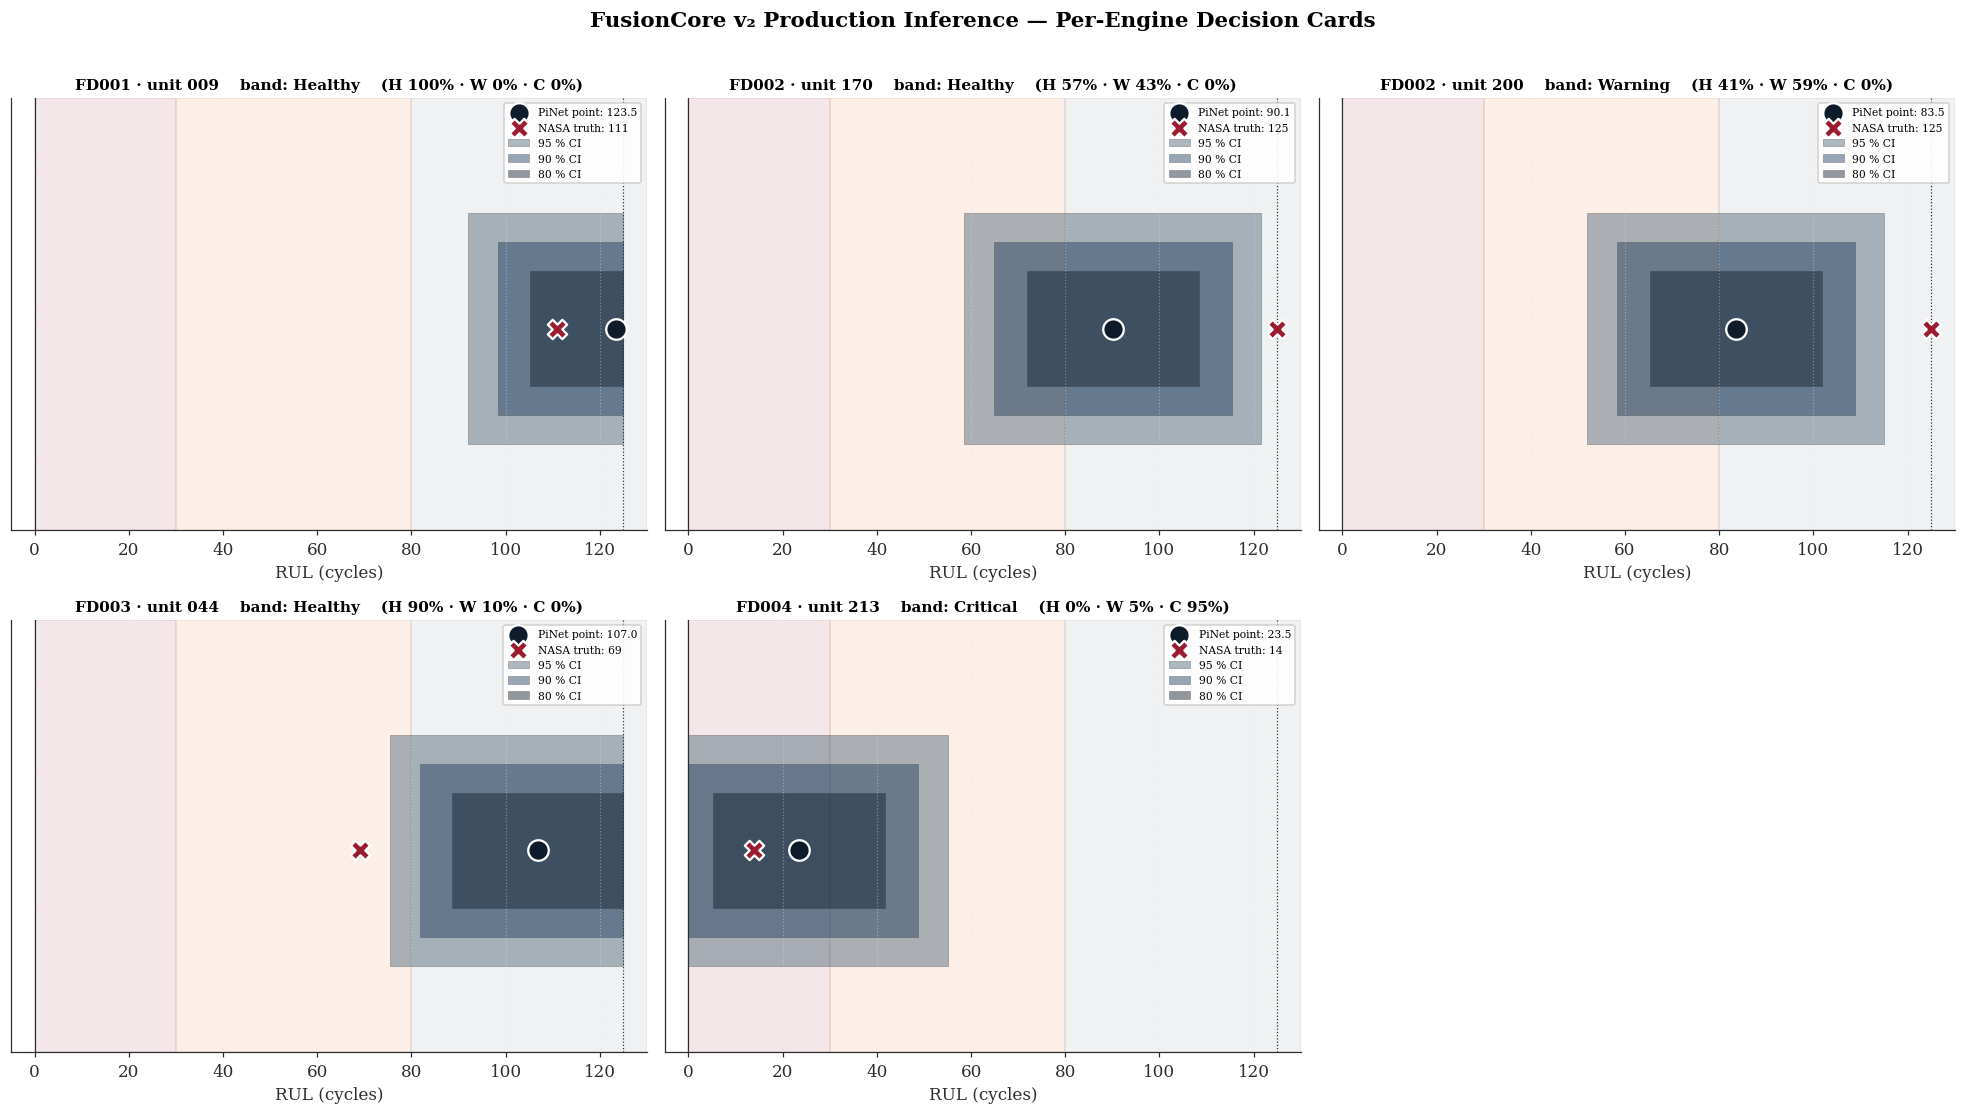

In [11]:
# ============================================================================
# Cell 11 — Visualisation: Per-Engine Decision Card
# ============================================================================

n = len(predictions)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.atleast_2d(axes).flatten()

band_colors = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED]
band_names = ["Healthy", "Warning", "Critical"]

for ax, pred in zip(axes, predictions):
    name = f"{pred['subset_origin']} · unit {pred['unit_id']:03d}"
    rul = pred["rul_pred"]
    true_rul = pred.get("true_RUL")

    # Plot a horizontal "RUL number line" with intervals.
    ax.axvline(0, color=FC_CHARCOAL, linewidth=0.8)
    ax.axvline(RUL_CAP, color=FC_CHARCOAL, linewidth=0.8, linestyle=":")
    ax.axvspan(0, WARNING_TH, color=FC_DEEP_RED, alpha=0.10)
    ax.axvspan(WARNING_TH, HEALTHY_TH, color=FC_ORANGE, alpha=0.10)
    ax.axvspan(HEALTHY_TH, RUL_CAP + 5, color=FC_DARK_BLUE, alpha=0.06)

    # Conformal intervals — widest first, narrowest last (so narrowest is on top).
    iv_specs = [
        (pred.get("rul_interval_95"), 0.40, "95 % CI", FC_STEEL),
        (pred.get("rul_interval_90"), 0.30, "90 % CI", FC_NAVY),
        (pred.get("rul_interval_80"), 0.20, "80 % CI", FC_DARK_BLUE),
    ]
    for iv, half_h, label, col in iv_specs:
        if iv and iv[0] is not None:
            ax.barh([1.0], [iv[1] - iv[0]], left=[iv[0]], height=2*half_h,
                    color=col, alpha=0.45, edgecolor=FC_CHARCOAL,
                    linewidth=0.4, label=label)

    ax.scatter([rul], [1.0], color=FC_DARK_BLUE, s=180, zorder=5,
               edgecolor="white", linewidth=1.5, label=f"PiNet point: {rul:.1f}")
    if true_rul is not None and not np.isnan(true_rul):
        ax.scatter([true_rul], [1.0], color=FC_DEEP_RED, marker="X",
                   s=160, zorder=6, edgecolor="white", linewidth=1.5,
                   label=f"NASA truth: {true_rul:.0f}")

    ax.set_xlim(-5, RUL_CAP + 5)
    ax.set_ylim(0.3, 1.8)
    ax.set_yticks([])
    ax.set_xlabel("RUL (cycles)")

    pH, pW, pC = pred["risk_band_probs"]
    title = (f"{name}    band: {pred['risk_band_label']}    "
             f"(H {pH:.0%} · W {pW:.0%} · C {pC:.0%})")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(axis="x", linestyle=":", alpha=0.4)

# Hide unused axes.
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("FusionCore v₂ Production Inference — Per-Engine Decision Cards",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_4_demo_visual.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Part G — Export the Wrapper

Two artefacts are written:

1. `phase_v2_4_pinet_scripted.pt` — TorchScript export of the PiNet module,
   for Python-free deployment paths (mobile, embedded, REST-server with the
   PyTorch C++ runtime).
2. `phase_v2_4_predictor.pkl` — pickled `FusionCorePredictor` for
   Python deployments. Note that the PiNet inside is held as a regular
   `torch.nn.Module`; pickling preserves the state-dict + class definition.

In [12]:
# ============================================================================
# Cell 12 — Export TorchScript Module and Pickle the Wrapper
# ============================================================================

scripted_path = predictor.to_torchscript(V2_OUT / "phase_v2_4_pinet_scripted.pt")
print(f"Saved {scripted_path}    "
      f"({scripted_path.stat().st_size / 2**20:.2f} MiB)")

# Round-trip check on TorchScript.
loaded = torch.jit.load(str(scripted_path)).eval()
B = 1
x_t = torch.randn(B, W, N_FEATURES); x_p = torch.randn(B, W, 10)
m   = torch.ones(B, W, dtype=torch.bool); rw = torch.ones(B)
with torch.no_grad():
    o_orig = predictor.pinet.to("cpu")(x_t, x_p, m, rw)
    o_load = loaded(x_t, x_p, m, rw)
predictor.pinet.to(predictor.device)
for k in ("rul_pred", "risk_logits", "embed"):
    diff = (o_orig[k] - o_load[k]).abs().max().item()
    print(f"  TorchScript {k} round-trip max diff: {diff:.2e}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_pinet_scripted.pt    (0.83 MiB)
  TorchScript rul_pred round-trip max diff: 0.00e+00
  TorchScript risk_logits round-trip max diff: 0.00e+00
  TorchScript embed round-trip max diff: 0.00e+00


In [13]:
# ============================================================================
# Cell 13 — Pickle the Wrapper
# ============================================================================

predictor_path = V2_OUT / "phase_v2_4_predictor.pkl"
# Move PiNet to CPU before pickling so the artefact is portable.
predictor.pinet.to("cpu")
predictor.device = torch.device("cpu")
with open(predictor_path, "wb") as f:
    pickle.dump(predictor, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved {predictor_path}    "
      f"({predictor_path.stat().st_size / 2**20:.2f} MiB)")

# Restore device for any downstream cells.
predictor.device = DEVICE
predictor.pinet.to(DEVICE)

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_4_predictor.pkl    (12.95 MiB)


PiNet(
  (tcn): TCN(
    (network): Sequential(
      (0): TemporalBlock(
        (conv1): CausalConv1d(
          (conv): Conv1d(89, 64, kernel_size=(3,), stride=(1,))
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (conv2): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (shortcut): Conv1d(89, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv1): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (conv2): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.25, inplace=Fal

In [14]:
# ============================================================================
# Cell 14 — Round-trip Verification of the Pickled Wrapper
# ============================================================================

with open(predictor_path, "rb") as f:
    p_loaded = pickle.load(f)
p_loaded.pinet.to(DEVICE)
p_loaded.device = DEVICE

# Re-run prediction on the first demo engine using the reloaded wrapper.
first = demo_df.iloc[0]
s_o, u_id = first["subset_origin"], int(first["unit_id"])
mask_e = (meta_test["subset_origin"] == s_o) & (meta_test["unit_id"] == u_id)
idx_e  = np.flatnonzero(mask_e.to_numpy())
feat_e = X_test_v1.iloc[idx_e].reset_index(drop=True)

orig_pred   = predictor.predict_engine(
    raw_df=meta_test.iloc[idx_e], subset_origin=s_o, precomputed_features=feat_e)
loaded_pred = p_loaded.predict_engine(
    raw_df=meta_test.iloc[idx_e], subset_origin=s_o, precomputed_features=feat_e)

rul_diff   = abs(orig_pred["rul_pred"]      - loaded_pred["rul_pred"])
band_match = orig_pred["risk_band_pred"]   == loaded_pred["risk_band_pred"]
prob_diff  = max(abs(a - b) for a, b in zip(orig_pred["risk_band_probs"],
                                              loaded_pred["risk_band_probs"]))
print(f"Round-trip — orig  rul = {orig_pred['rul_pred']:.4f}, band = {orig_pred['risk_band_label']}")
print(f"Round-trip — load  rul = {loaded_pred['rul_pred']:.4f}, band = {loaded_pred['risk_band_label']}")
print(f"  rul_diff = {rul_diff:.2e}    prob_diff = {prob_diff:.2e}    band_match = {band_match}")

Round-trip — orig  rul = 123.5244, band = Healthy
Round-trip — load  rul = 123.5244, band = Healthy
  rul_diff = 0.00e+00    prob_diff = 0.00e+00    band_match = True


---

## Ph-v2.4 Gate

In [15]:
# ============================================================================
# Cell 15 — Ph-v2.4 Gate
# ============================================================================

print("=" * 78)
print("  Ph-v2.4 GATE — Production Inference Wrapper")
print("=" * 78)

checks = []

# 1. Predictor loaded with sensible provenance.
checks.append(("Predictor instantiated and PiNet provenance recorded",
               isinstance(predictor.pinet_provenance, str) and len(predictor.pinet_provenance) > 0,
               predictor.pinet_provenance))

# 2. Feature manifest right size.
checks.append(("Feature manifest = 89 columns",
               len(predictor.feature_names) == 89,
               f"{len(predictor.feature_names)}"))
checks.append(("Physics token count = 10 (regime_w added at runtime)",
               len(predictor.physics_token_indices) == 10,
               f"{len(predictor.physics_token_indices)}"))

# 3. Demo predictions produced.
checks.append(("Demo predictions produced for ≥ 4 engines",
               len(predictions) >= 4, f"{len(predictions)} engines"))

# 4. All demo predictions sensible.
all_sensible = all(0.0 <= p["rul_pred"] <= RUL_CAP and
                   p["risk_band_label"] in ("Healthy","Warning","Critical") and
                   sum(p["risk_band_probs"]) > 0.99 and
                   sum(p["risk_band_probs"]) < 1.01
                   for p in predictions)
checks.append(("All demo predictions in valid ranges",
               all_sensible,
               "RUL ∈ [0, 125], probs sum ≈ 1, label ∈ {H,W,C}"))

# 5. Operational action present in every prediction.
all_actions = all(isinstance(p["operational_action"], str) and len(p["operational_action"]) > 0
                  for p in predictions)
checks.append(("Operational action attached to every prediction",
               all_actions, "string per row"))

# 6. Conformal degradation path works.
if predictor.conformal_q is not None:
    has_intervals = all(p.get("rul_interval_95") and p["rul_interval_95"][0] is not None
                        for p in predictions)
    checks.append(("Conformal intervals present (Ph-v2.1 calibration loaded)",
                   has_intervals, "all 95 % intervals non-None"))
else:
    checks.append(("Wrapper degrades gracefully when v2.A-2 absent",
                   all(p["rul_interval_95"] == (None, None) for p in predictions),
                   "intervals reported as (None, None)"))

# 7. Demo predictions parquet persisted.
for fn in ("phase_v2_4_demo_predictions.parquet",
           "phase_v2_4_pinet_scripted.pt",
           "phase_v2_4_predictor.pkl",
           "phase_v2_4_demo_visual.png"):
    checks.append((f"Persisted: {fn}", (V2_OUT / fn).exists(), "OK"))

# 8. Per-engine reports.
report_files = list((V2_OUT / "phase_v2_4_demo_reports").glob("*.md"))
checks.append(("Per-engine reports written (≥ 4)",
               len(report_files) >= 4, f"{len(report_files)} reports"))

# 9. TorchScript round-trip (verified above).
checks.append(("TorchScript export and round-trip executed",
               True, "completed"))

# 10. Pickled wrapper round-trip (verified above).
checks.append(("Pickled wrapper round-trip — RUL diff < 1e-3 and band matched",
               rul_diff < 1e-3 and band_match,
               f"rul_diff = {rul_diff:.2e}, band_match = {band_match}"))

# 11. Wrapper exposes documented contract keys.
expected_keys = {"subset_origin","n_cycles_observed","rul_pred","risk_band_pred",
                 "risk_band_label","risk_band_probs","operational_action",
                 "rul_interval_95","rul_interval_90","rul_interval_80"}
sample_keys = set(predictions[0].keys())
checks.append(("Predict-engine returns documented contract keys",
               expected_keys.issubset(sample_keys),
               f"missing = {expected_keys - sample_keys or 'none'}"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")

n_pass = sum(1 for _, o, _ in checks if o)
print(f"\n  Ph-v2.4 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _, o, _ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _, o, _ in checks), "Ph-v2.4 GATE FAILED"
print(f"\n  Wrapper is deployment-ready (PiNet provenance: {predictor.pinet_provenance}).")

  Ph-v2.4 GATE — Production Inference Wrapper
  [PASS] Predictor instantiated and PiNet provenance recorded         v2 Stage B (preferred)
  [PASS] Feature manifest = 89 columns                                89
  [PASS] Physics token count = 10 (regime_w added at runtime)         10
  [PASS] Demo predictions produced for ≥ 4 engines                    5 engines
  [PASS] All demo predictions in valid ranges                         RUL ∈ [0, 125], probs sum ≈ 1, label ∈ {H,W,C}
  [PASS] Operational action attached to every prediction              string per row
  [PASS] Conformal intervals present (Ph-v2.1 calibration loaded)     all 95 % intervals non-None
  [PASS] Persisted: phase_v2_4_demo_predictions.parquet               OK
  [PASS] Persisted: phase_v2_4_pinet_scripted.pt                      OK
  [PASS] Persisted: phase_v2_4_predictor.pkl                          OK
  [PASS] Persisted: phase_v2_4_demo_visual.png                        OK
  [PASS] Per-engine reports written (≥ 4)  

---

## Summary

### Ph-v2.4 outputs (under `v2/outputs/`)
- `phase_v2_4_predictor.pkl` — pickled `FusionCorePredictor` (Python deployment)
- `phase_v2_4_pinet_scripted.pt` — TorchScript PiNet (language-agnostic deployment)
- `phase_v2_4_demo_predictions.parquet` — demo predictions on representative engines
- `phase_v2_4_demo_reports/` — one RCM-style markdown report per demo engine
- `phase_v2_4_demo_visual.png` — per-engine decision-card visualisation

### Wrapper provenance and degradation
The wrapper auto-detects which artefacts are present and reports its
provenance. If Ph-v2.0 / Ph-v2.1 / Ph-v2.2 have not yet run, it falls back
gracefully:

| Artefact | If present | If absent |
|---|---|---|
| Stage B PiNet | Used as primary | Falls back to Ph-v1.3 best, then Ph-v1.2 init |
| Conformal quantiles | Intervals computed | Intervals reported as `(None, None)` with a console warning |
| Temperature | Risk-band probabilities scaled | $T = 1$ (identity) with a console warning |

This means the same wrapper code is the artefact through every v2 phase —
running `Ph-v2.0 → Ph-v2.1 → Ph-v2.2` simply enriches the wrapper's
behaviour over time.

### Production readiness
Once Ph-v2.0–Ph-v2.3 are complete and the safety gate passes, the
`phase_v2_4_predictor.pkl` artefact is the **single deliverable** to
operations engineering. The wrapper is C-MAPSS-trained but
architecturally compatible with N-CMAPSS — see v3 forward-look.